# Adult Dataset - Income Prediction ML Project (PyCaret)

### Name: Shaima Alqahtani

## 1. Problem Framing

**Goal:**  
Predict whether a person’s income is `>50K` or `<=50K` based on demographic features.

**Current / non-ML solution:**  
Manual or simple statistical analysis cannot handle large datasets or complex feature interactions

**Application, Goal, Description:**  
Helps governments, employers, and researchers understand income‑related factors

**ML Task:**  
Binary Classification (Supervised Learning).

**Why ML? (Use case, Cost, Maintenance, Expertise):**  
- Large dataset
- Non‑linear relationships
- ML reduces cost and time
- Low maintenance required

## 2. Data

- **Source:** Extracted from the 1994 U.S. Census by Barry Becker.
- **Quantity:** ~48K rows.
- **Quality:** Mixed numeric + categorical, missing values handled by PyCaret.
- **ART check:**  
  - **A**ppropriate: Features logically related to income.  
  - **R**epresentative: Contains diverse demographic groups (but should be audited for bias).  
  - **T**imely: Static dataset; retraining needed if population changes.

## 3. Features

- Raw features: age, workclass, education, marital-status, occupation, relationship, race, sex, hours-per-week, etc.
- Engineered features:  
  - Encodings for categoricals  
  - Scaling / normalization  
  - Multicollinearity removal

Feature importance is inspected via `plot_model(best_model, plot="feature")`.

## 4. Model & Metrics

- **Library:** PyCaret (classification module)
- **Model selection:** `compare_models()` chooses best-performing model.
- **Target:** `income` (`>50K`, `<=50K`)
- **Metrics:** Accuracy, AUC, F1, Precision, Recall (from PyCaret summary table).

**Success criteria:**

- AUC > 0.85
- Balanced performance across both classes.

In [50]:
# تحميل من الموقع 

from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 


{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [51]:
import pandas as pd

df = X.copy()
df['income'] = y.iloc[:, 0]
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K.
48838,64,NaN,321403,HS-grad,9,Widowed,NaN,Other-relative,Black,Male,0,0,40,United-States,<=50K.
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K.
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K.


In [52]:
# معالجه البيانات المفقوده

import numpy as np

df = df.replace("?", np.nan)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])


In [53]:
# pycaret
from pycaret.classification import *

s = setup(
    data=df,
    target='income',
    session_id=42,
    normalize=True,
    train_size=0.8
)


,Description,Value
0,Session id,42
1,Target,income
2,Target type,Multiclass
3,Target mapping,"<=50K: 0, <=50K.: 1, >50K: 2, >50K.: 3"
4,Original data shape,"(48842, 15)"
5,Transformed data shape,"(48842, 65)"
6,Transformed train set shape,"(39073, 65)"
7,Transformed test set shape,"(9769, 65)"
8,Numeric features,6
9,Categorical features,8


In [54]:
# مقارنة النماذج
best_model = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.5772,0.7234,0.5772,0.4784,0.4682,0.2538,0.3064,1.3680
gbc,Gradient Boosting Classifier,0.5746,0.0000,0.5746,0.4562,0.4576,0.2350,0.2983,8.5730
ada,Ada Boost Classifier,0.5717,0.0000,0.5717,0.4241,0.4546,0.2359,0.2945,1.0000
lr,Logistic Regression,0.5667,0.0000,0.5667,0.4019,0.4504,0.2279,0.2840,1.2650
lda,Linear Discriminant Analysis,0.5594,0.0000,0.5594,0.3788,0.4432,0.2107,0.2657,0.5390
ridge,Ridge Classifier,0.5582,0.0000,0.5582,0.3682,0.4397,0.1960,0.2576,0.3190
svm,SVM - Linear Kernel,0.5502,0.0000,0.5502,0.4399,0.4505,0.2093,0.2491,1.0700
rf,Random Forest Classifier,0.5251,0.6895,0.5251,0.4669,0.4793,0.2057,0.2167,2.0560
dummy,Dummy Classifier,0.5061,0.5000,0.5061,0.2561,0.3401,0.0000,0.0000,0.2980
knn,K Neighbors Classifier,0.4940,0.6422,0.4940,0.4488,0.4604,0.1545,0.1602,0.8850


In [55]:
# تثبيت النموذج النهائي
final_model = finalize_model(best_model)

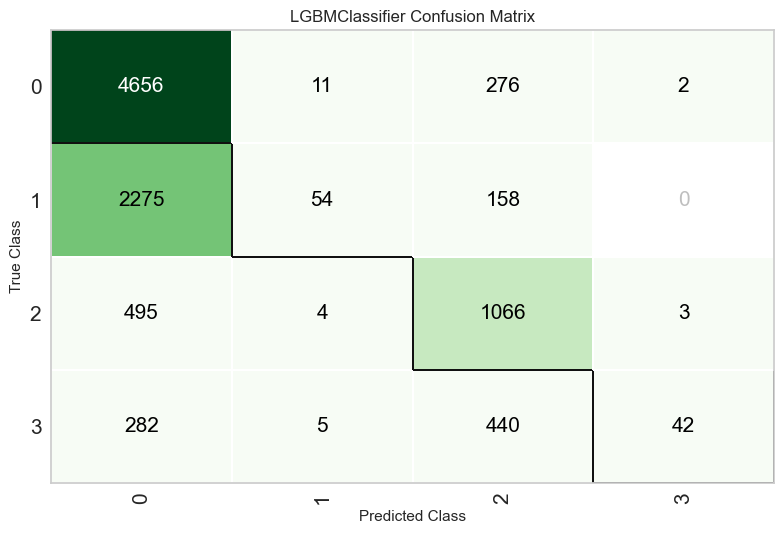

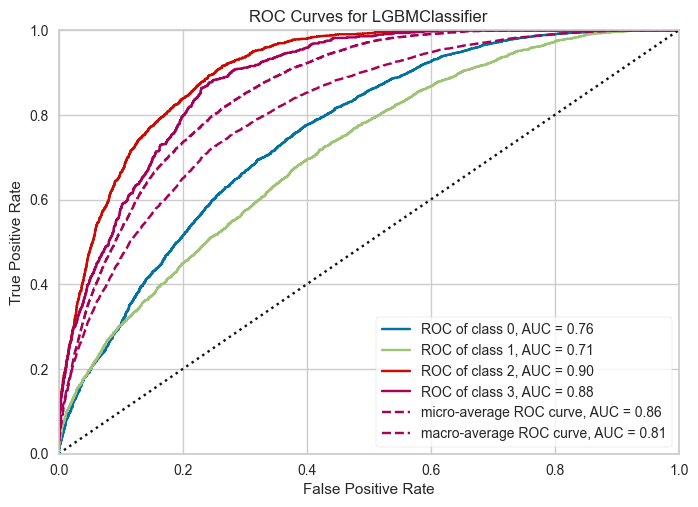

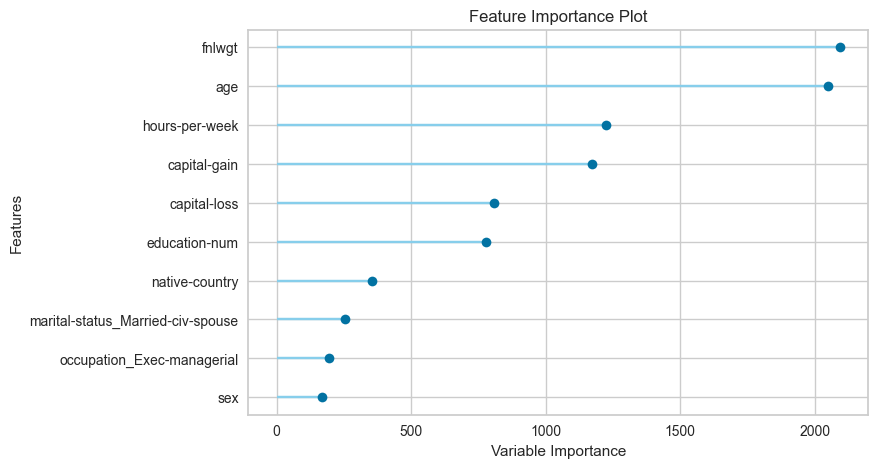

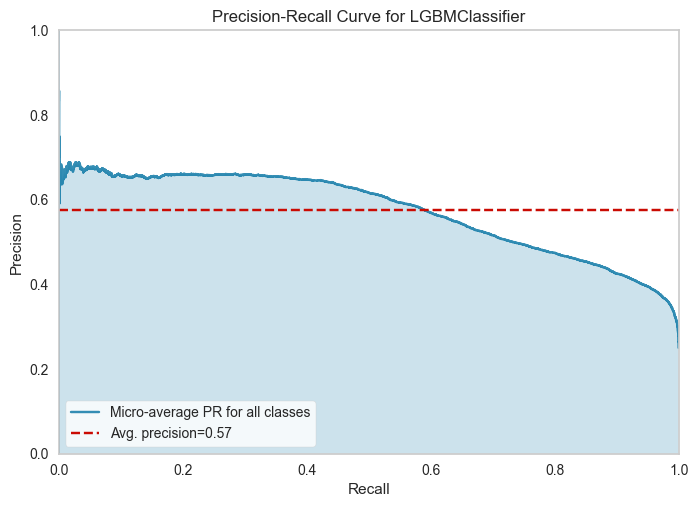

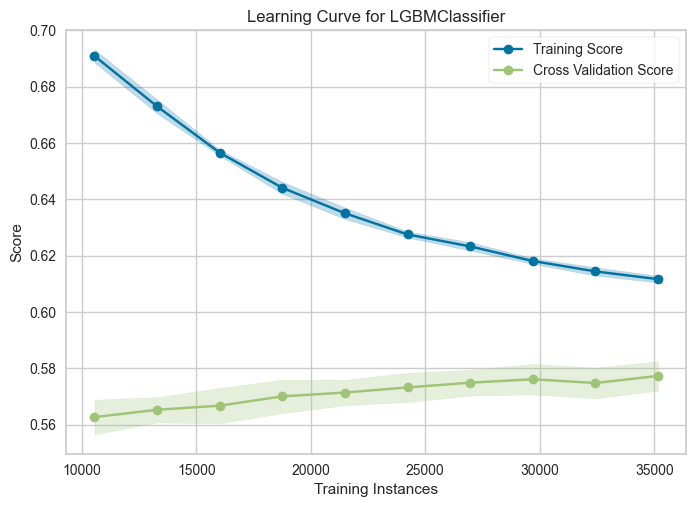

In [56]:
# الرسمات المهمه
plot_model(final_model, plot='confusion_matrix')
plot_model(final_model, plot='auc')
plot_model(final_model, plot='feature')
plot_model(final_model, plot='pr')
plot_model(final_model, plot='learning')

**1. Confusion Matrix:**
The confusion matrix shows how many predictions were correct vs. incorrect for each class.

- Rows = True class

- Columns = Predicted class

- Diagonal = Correct predictions

- Off‑diagonal = Misclassifications

model performs best on Class 0 and Class 2, and struggles with Class 3.

**2. ROC Curve:**
The ROC curve shows how well the model separates the classes.
Higher AUC = better discrimination.

model is very strong for Class 2 and Class 3, and acceptable for Class 0 and Class 1.


**3. Feature Importance:**
Feature importance shows which variables contribute most to the model’s decisions.

model relies heavily on:

- fnlwgt

- age

- working hours

- capital gain/loss

- education level

Gender has almost no impact.

**4. Precision–Recall Curve:**
The PR curve shows how well the model balances precision and recall.

model is average precision is 0.57, which is moderate.
It performs better on some classes than others.

**5. Learning Curve:**
- Training score decreases slightly

- Validation score increases

- The gap is small → good generalization

- No overfitting

In [57]:
# تقييم النموذج
evaluate_model(final_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [58]:
# حفظ النموذج
save_model(final_model, 'income_classifier')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['age', 'fnlwgt', 'education-num',
                                              'capital-gain', 'capital-loss',
                                              'hours-per-week'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, importance_type='split',
                                 learning_rate=0.1, max_depth=-1,
       

In [59]:
# شامل
import gradio as gr
import pandas as pd
from pycaret.classification import load_model, predict_model

# Load the trained model
model = load_model("income_classifier")

# Dropdown lists (Adult Dataset categories)
workclass_list = [
    "Private", "Self-emp-not-inc", "Self-emp-inc", "Federal-gov",
    "Local-gov", "State-gov", "Without-pay", "Never-worked"
]

education_list = [
    "Bachelors", "Some-college", "11th", "HS-grad", "Prof-school",
    "Assoc-acdm", "Assoc-voc", "9th", "7th-8th", "12th", "Masters",
    "1st-4th", "10th", "Doctorate", "5th-6th", "Preschool"
]

marital_list = [
    "Married-civ-spouse", "Divorced", "Never-married",
    "Separated", "Widowed", "Married-spouse-absent"
]

occupation_list = [
    "Tech-support", "Craft-repair", "Other-service", "Sales",
    "Exec-managerial", "Prof-specialty", "Handlers-cleaners",
    "Machine-op-inspct", "Adm-clerical", "Farming-fishing",
    "Transport-moving", "Priv-house-serv", "Protective-serv",
    "Armed-Forces"
]

relationship_list = [
    "Wife", "Own-child", "Husband", "Not-in-family",
    "Other-relative", "Unmarried"
]

race_list = [
    "White", "Black", "Asian-Pac-Islander",
    "Amer-Indian-Eskimo", "Other"
]

sex_list = ["Male", "Female"]

country_list = [
    "United-States", "Mexico", "Philippines", "Germany", "Canada",
    "India", "Japan", "China", "England", "Italy", "France",
    "Dominican-Republic", "Vietnam", "Poland", "Columbia"
]

# Prediction function
def predict_income(age, workclass, fnlwgt, education, education_num,
                   marital_status, occupation, relationship, race, sex,
                   capital_gain, capital_loss, hours_per_week, native_country):

    data = pd.DataFrame([{
        "age": age,
        "workclass": workclass,
        "fnlwgt": fnlwgt,
        "education": education,
        "education-num": education_num,
        "marital-status": marital_status,
        "occupation": occupation,
        "relationship": relationship,
        "race": race,
        "sex": sex,
        "capital-gain": capital_gain,
        "capital-loss": capital_loss,
        "hours-per-week": hours_per_week,
        "native-country": native_country
    }])

    prediction = predict_model(model, data=data)
    label = prediction["prediction_label"][0]
    score = prediction["prediction_score"][0]

    return label, round(score, 3)

# Gradio Interface
interface = gr.Interface(
    fn=predict_income,
    inputs=[
        gr.Number(label="Age"),
        gr.Dropdown(workclass_list, label="Workclass"),
        gr.Number(label="FNLWGT"),
        gr.Dropdown(education_list, label="Education"),
        gr.Number(label="Education Num"),
        gr.Dropdown(marital_list, label="Marital Status"),
        gr.Dropdown(occupation_list, label="Occupation"),
        gr.Dropdown(relationship_list, label="Relationship"),
        gr.Dropdown(race_list, label="Race"),
        gr.Dropdown(sex_list, label="Sex"),
        gr.Number(label="Capital Gain"),
        gr.Number(label="Capital Loss"),
        gr.Number(label="Hours per Week"),
        gr.Dropdown(country_list, label="Native Country")
    ],
    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Confidence")
    ],
    title="Adult Dataset - Income Prediction",
    description="Predict whether income is >50K or <=50K using the Adult Census Dataset."
)

interface.launch()


Transformation Pipeline and Model Successfully Loaded
* Running on local URL:  http://127.0.0.1:7871
* To create a public link, set `share=True` in `launch()`.


In [ ]:
# مبسط

import gradio as gr
import pandas as pd
from pycaret.classification import load_model, predict_model

# Load trained model
model = load_model("income_classifier")

# Education list
education_list = [
    "Bachelors", "Some-college", "HS-grad", "Prof-school",
    "Assoc-acdm", "Assoc-voc", "Masters",
    "Doctorate"
]

# Country list
country_list = [
    "United-States", "Mexico", "Philippines", "Germany", "Canada",
    "India", "Japan", "China", "England", "Italy", "France",
    "Dominican-Republic", "Vietnam", "Poland", "Columbia"
]

# Prediction function
def predict_income(age, hours_per_week, capital_gain, capital_loss, education, native_country):

    data = pd.DataFrame([{
        "age": age,
        "hours-per-week": hours_per_week,
        "capital-gain": capital_gain,
        "capital-loss": capital_loss,
        "education": education,
        "native-country": native_country,

        # Default values for missing columns
        "workclass": "Private",
        "fnlwgt": 100000,
        "education-num": 10,
        "marital-status": "Never-married",
        "occupation": "Adm-clerical",
        "relationship": "Not-in-family",
        "race": "White",
        "sex": "Female"
    }])

    prediction = predict_model(model, data=data)
    label = prediction["prediction_label"][0]

    return label

# Gradio Interface
interface = gr.Interface(
    fn=predict_income,
    inputs=[
        gr.Number(label="Age"),
        gr.Number(label="Hours per Week"),
        gr.Number(label="Capital Gain"),
        gr.Number(label="Capital Loss"),
        gr.Dropdown(education_list, label="Education Level"),
        gr.Dropdown(country_list, label="Native Country")
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="Adult Dataset - Income Prediction",
    description="Predict whether income is >50K or <=50K using simplified inputs."
)

interface.launch()


Transformation Pipeline and Model Successfully Loaded
* Running on local URL:  http://127.0.0.1:7876
* To create a public link, set `share=True` in `launch()`.
